# Rope Flow — Full Pipeline V07
## Topology Features + Cycle-Matrix PCA + Min-Cycle Filter

**Course:** MECH 798M / EECE 798K — Data-Driven Modeling  
**Base:** V06 (tuning, heterogeneous sessions, transition rejection)  
**V07 additions:**
- 10D topology features (cross-axis phase lags, plane-of-motion ratio, winding number)
- 10D cycle-matrix PCA shape features (flattened waveform projected onto PCA basis)  
- Min-cycle filter (entries with <5 cycles excluded from training)
- Randomized train/test split (different each run)
- Feature dimension: 56D → 76D

## V06 IMPROVEMENTS (ML Performance Fixes)

### Key Changes from V05.2

1. **Removed per-session z-scoring in training** (Line ~680 in train_model_v05)
   - **Problem**: Per-session z-scoring inflated LOSO performance differences
   - **Solution**: Use global StandardScaler fitted on ALL training data
   - **Expected gain**: LOSO F1 should rise significantly (0.32 → ~0.45-0.55)
   - **Expected side effect**: Test F1 may drop slightly (0.643 → ~0.55-0.60) — more realistic

2. **Aligned scaling consistency between LOSO and test**
   - Both now use same global StandardScaler fitted on training data
   - Removes scaling mismatch that favored test set

3. **Added class balance diagnostics** (in train_model_v05 verbose output)
   - Warns if class imbalance ratio > 3x
   - Suggests `class_weight='balanced'` if needed

4. **All zero-cycle handling preserved** ✓
   - Sessions with 0 cycles still skip evaluation
   - 'unknown' class still supported
   - Confidence gating still in place

### Expected Performance Change

Before (V05.2):  LOSO F1=0.320,  Test F1=0.643  (gap: 2.0x — INVERTED overfitting)
After (V06):     LOSO F1~0.45,   Test F1~0.55   (gap: 1.2x — normal variance)

### Validation Steps

1. Run LOSO CV — should see improvement in training
2. Check test set — should be more realistic (lower than before)
3. Look for class balance warnings in train output
4. Compare per-fold LOSO scores — should be more consistent


In [13]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy.linalg import svd
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Paths ────────────────────────────────────────────────────
DATA_PROCESSED = os.path.join('..', '..', 'data', 'processed')

CONFIG = {
    'FS': 50.0,
    'CYCLE_PROMINENCE_DEGS': 100.0,
    'CYCLE_MIN_PERIOD_S': 0.5,
    'CYCLE_MAX_PERIOD_S': 3.0,
    'TARGET_LEN': 64,
    'N_FOURIER_HARMONICS': 5,
    'PCA_COMPONENTS': 6,
    'TEMPLATE_CORR_THRESHOLD': 0.60,
    'OCSVM_NU': 0.1,
    'OCSVM_GAMMA': 'scale',
    'MIN_CYCLE_SAMPLES': 10,
    'CONFIDENCE_THRESHOLD': 0.7,      # GBM confidence gate for transition rejection
    'TEMPLATE_GATE_THRESHOLD': 0.2,   # min template corr to accept a cycle
}

MACRO_MAP = {
    'underhand': 'foundational', 'overhand': 'foundational',
    'dragon_roll': 'advanced',
    'sneak_underhand': 'sneak', 'sneak_overhand': 'sneak',
    'race_and_chase': 'advanced', 'cheetahs_tail': 'advanced',
}

KNOWN_PATTERNS = set(MACRO_MAP.keys())

PAL = {
    'overhand': '#7F77DD', 'underhand': '#5DCAA5', 'dragon_roll': '#E24B4A',
    'sneak_overhand': '#D85A30', 'sneak_underhand': '#EF9F27',
    'race_and_chase': '#3498db', 'cheetahs_tail': '#e74c3c',
    'transition': '#CCCCCC', 'unknown': '#888888',
}

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})


# ── Results directory (new folder per run) ───────────────────
import datetime
RUN_NAME = datetime.datetime.now().strftime('run_%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('..', '..', 'results', 'Full_pipeline', RUN_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')


# ── Results directory (new folder per run) ───────────────────
import datetime
RUN_NAME = datetime.datetime.now().strftime('run_%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('..', '..', 'results', 'Full_pipeline', RUN_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results will be saved to: {RESULTS_DIR}')


Results will be saved to: ..\..\results\Full_pipeline\run_20260419_133211
Results will be saved to: ..\..\results\Full_pipeline\run_20260419_133211


---
## 2. Core pipeline functions (V02 — validated)
All feature extraction, template, and base classification functions reused verbatim from v05.

In [14]:
def load_session(path_d0, path_d1):
    d0 = pd.read_csv(path_d0)
    d1 = pd.read_csv(path_d1)
    return d0, d1

def extract_signals(df):
    t = df['timestamp_ms'].values / 1000.0
    A = df[['ax_w', 'ay_w', 'az_w']].values
    omega = df[['gx', 'gy', 'gz']].values * (np.pi / 180.0)
    Q = df[['qw', 'qx', 'qy', 'qz']].values
    return t, Q, A, omega

# ══════════════════════════════════════════════════════════════
# 2. Cycle detection
# ══════════════════════════════════════════════════════════════
def detect_cycles(t, omega, fs=50.0):
    mag = np.linalg.norm(omega, axis=1)
    mag_smooth = savgol_filter(mag, window_length=15, polyorder=3)
    prom_rads = CONFIG['CYCLE_PROMINENCE_DEGS'] * np.pi / 180.0
    min_dist = int(CONFIG['CYCLE_MIN_PERIOD_S'] * fs)
    peaks, _ = find_peaks(mag_smooth, distance=min_dist, prominence=prom_rads)
    if len(peaks) < 2:
        return [], mag_smooth, peaks
    bounds = ([0]
              + [(peaks[i] + peaks[i+1]) // 2 for i in range(len(peaks) - 1)]
              + [len(t) - 1])
    cycles = [(bounds[i], bounds[i+1]) for i in range(len(bounds) - 1)]
    valid = []
    for s, e in cycles:
        dur = t[e] - t[s]
        if (dur >= CONFIG['CYCLE_MIN_PERIOD_S'] and
            dur <= CONFIG['CYCLE_MAX_PERIOD_S'] and
            (e - s) >= CONFIG['MIN_CYCLE_SAMPLES']):
            valid.append((s, e))
    return valid, mag_smooth, peaks

def pair_cycles(t0, cyc0, t1, cyc1):
    def overlap(s0, e0, s1, e1):
        return max(0.0, min(t0[e0], t1[e1]) - max(t0[s0], t1[s1]))
    paired0, paired1, used = [], [], set()
    for c0 in cyc0:
        best_idx, best_ov = -1, -1.0
        for i, c1 in enumerate(cyc1):
            if i in used:
                continue
            ov = overlap(c0[0], c0[1], c1[0], c1[1])
            if ov > best_ov:
                best_ov, best_idx = ov, i
        if best_idx >= 0 and best_ov > 0:
            paired0.append(c0)
            paired1.append(cyc1[best_idx])
            used.add(best_idx)
    return paired0, paired1

# ══════════════════════════════════════════════════════════════
# 3. Fourier decomposition
# ══════════════════════════════════════════════════════════════
def fourier_features(signal_segment, fs, n_harmonics=5):
    N = len(signal_segment)
    if N < 8:
        return np.zeros(3 + n_harmonics)
    sig = signal_segment - np.mean(signal_segment)
    F = np.abs(np.fft.rfft(sig))
    freqs = np.fft.rfftfreq(N, 1.0 / fs)
    F[0] = 0
    power = F ** 2
    total_power = np.sum(power) + 1e-12
    dom_idx = np.argmax(F[1:]) + 1
    dom_freq = freqs[dom_idx]
    spectral_centroid = np.sum(freqs * power) / total_power
    f0 = dom_freq
    harmonic_ratios = np.zeros(n_harmonics)
    for h in range(n_harmonics):
        target_freq = f0 * (h + 1)
        if target_freq > freqs[-1]:
            break
        idx = np.argmin(np.abs(freqs - target_freq))
        lo = max(1, idx - 1)
        hi = min(len(F), idx + 2)
        harmonic_ratios[h] = np.sum(power[lo:hi]) / total_power
    p_norm = power[1:] / (np.sum(power[1:]) + 1e-12)
    p_norm = p_norm[p_norm > 0]
    spectral_entropy = -np.sum(p_norm * np.log2(p_norm + 1e-12))
    return np.concatenate([[dom_freq, spectral_centroid, spectral_entropy],
                           harmonic_ratios])

def cycle_fourier_features(A, omega, s, e, fs):
    nh = CONFIG['N_FOURIER_HARMONICS']
    feats = []
    omega_mag = np.linalg.norm(omega[s:e], axis=1)
    feats.append(fourier_features(omega_mag, fs, nh))
    acc_mag = np.linalg.norm(A[s:e], axis=1)
    feats.append(fourier_features(acc_mag, fs, nh))
    return np.concatenate(feats)

FOURIER_DIM = 2 * (3 + CONFIG['N_FOURIER_HARMONICS'])
FOURIER_NAMES = []
for ch in ['omega_mag', 'acc_mag']:
    FOURIER_NAMES += [f'{ch}_dom_freq', f'{ch}_spec_centroid', f'{ch}_spec_entropy']
    FOURIER_NAMES += [f'{ch}_harm_{i}' for i in range(CONFIG['N_FOURIER_HARMONICS'])]

# ══════════════════════════════════════════════════════════════
# 4. Physics-grounded features
# ══════════════════════════════════════════════════════════════
def physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs):
    tc0, tc1 = t0[s0:e0], t1[s1:e1]
    a0, a1 = A0[s0:e0], A1[s1:e1]
    w0, w1 = om0[s0:e0], om1[s1:e1]
    period = tc0[-1] - tc0[0]
    m0 = np.linalg.norm(w0, axis=1)
    m1 = np.linalg.norm(w1, axis=1)
    peak_omega = max(np.max(m0), np.max(m1))
    mean_omega_d0 = np.mean(m0)
    mean_omega_d1 = np.mean(m1)
    acc_rms_d0 = np.sqrt(np.mean(np.sum(a0**2, axis=1)))
    acc_rms_d1 = np.sqrt(np.mean(np.sum(a1**2, axis=1)))
    acc_asym = acc_rms_d0 / (acc_rms_d1 + 1e-8)
    omega_ratio = np.std(m0) / (np.std(m1) + 1e-8)
    n_min = min(len(m0), len(m1))
    if n_min > 4:
        c0 = m0[:n_min] - m0[:n_min].mean()
        c1 = m1[:n_min] - m1[:n_min].mean()
        corr = np.correlate(c0, c1, mode='full')
        lag_samples = np.argmax(corr) - (n_min - 1)
        phase_lag = lag_samples / fs * 1000
    else:
        phase_lag = 0.0
    if len(a0) > 2:
        jerk = np.diff(a0, axis=0) * fs
        jerk_rms = np.sqrt(np.mean(np.sum(jerk**2, axis=1)))
    else:
        jerk_rms = 0.0
    e_rot = np.mean(m0**2) + np.mean(m1**2)
    e_lin = np.mean(np.sum(a0**2, axis=1)) + np.mean(np.sum(a1**2, axis=1))
    ke_ratio = e_rot / (e_rot + e_lin + 1e-8)
    if len(m0) > 10:
        m0c = m0 - m0.mean()
        ac = np.correlate(m0c, m0c, mode='full')
        ac = ac[len(m0c)-1:]
        ac /= (ac[0] + 1e-12)
        min_lag = max(2, int(0.3 * fs))
        peaks_ac, props = find_peaks(ac[min_lag:], height=0)
        periodicity = props['peak_heights'][0] if len(peaks_ac) > 0 else 0.0
    else:
        periodicity = 0.0
    return np.array([
        period, peak_omega, mean_omega_d0, mean_omega_d1,
        acc_rms_d0, acc_rms_d1, acc_asym, omega_ratio,
        phase_lag, jerk_rms, ke_ratio, periodicity
    ])

PHYSICS_NAMES = [
    'period_s', 'peak_omega', 'mean_omega_d0', 'mean_omega_d1',
    'acc_rms_d0', 'acc_rms_d1', 'acc_asymmetry', 'omega_std_ratio',
    'phase_lag_ms', 'jerk_rms', 'ke_ratio', 'periodicity_score'
]

# ══════════════════════════════════════════════════════════════
# 5. SVD features
# ══════════════════════════════════════════════════════════════
def resample_cycle(signal, target_len):
    n = len(signal)
    if n < 2:
        return np.zeros(target_len) if signal.ndim == 1 else np.zeros((target_len, signal.shape[1]))
    x_old = np.linspace(0, 1, n)
    x_new = np.linspace(0, 1, target_len)
    if signal.ndim == 1:
        return np.interp(x_new, x_old, signal)
    else:
        return np.column_stack([np.interp(x_new, x_old, signal[:, j])
                                for j in range(signal.shape[1])])

def build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, target_len=64):
    state0 = np.column_stack([A0[s0:e0], om0[s0:e0]])
    state1 = np.column_stack([A1[s1:e1], om1[s1:e1]])
    r0 = resample_cycle(state0, target_len)
    r1 = resample_cycle(state1, target_len)
    return np.column_stack([r0, r1]).T  # (12, target_len)

def compute_svd_features(cycle_matrix, n_components=6):
    U, S, Vt = svd(cycle_matrix, full_matrices=False)
    S_ratio = S[:n_components] / (S[0] + 1e-12)
    eff_rank = np.sum(S > 0.01 * S[0])
    total_energy = np.sum(S**2)
    return np.concatenate([S_ratio, [eff_rank, total_energy]])

SVD_DIM = CONFIG['PCA_COMPONENTS'] + 2
SVD_NAMES = ([f'sv_ratio_{i}' for i in range(CONFIG['PCA_COMPONENTS'])]
             + ['eff_rank', 'total_energy'])

# ══════════════════════════════════════════════════════════════
# 6. Template correlation
# ══════════════════════════════════════════════════════════════
def phase_align(cycle_matrix, reference, ref_channel=3):
    """
    Circularly shift cycle_matrix to maximize correlation with reference
    on a chosen channel (default: ωx of D0, row 3).
    This removes arbitrary phase offset from cycle segmentation.
    """
    x = cycle_matrix[ref_channel]
    y = reference[ref_channel]
    x_c = x - np.mean(x)
    y_c = y - np.mean(y)
    corr = np.correlate(np.tile(x_c, 2), y_c, mode='valid')
    shift = np.argmax(corr)
    if shift >= len(x):
        shift -= len(x)
    aligned = np.roll(cycle_matrix, -shift, axis=1)
    return aligned, shift


def build_template(all_cycle_matrices):
    """
    Build overhand template via iterative phase alignment.
    1. Initial template = median-energy cycle
    2. Phase-align all cycles to it
    3. Average the IQR-filtered aligned cycles
    """
    energies = np.array([np.sum(m**2) for m in all_cycle_matrices])
    # Start from the cycle closest to median energy
    median_idx = np.argmin(np.abs(energies - np.median(energies)))
    template = all_cycle_matrices[median_idx].copy()

    # Iterative refinement (2 passes)
    for iteration in range(2):
        aligned = []
        for cm in all_cycle_matrices:
            cm_a, _ = phase_align(cm, template)
            aligned.append(cm_a)
        # IQR filter on energy
        q25, q75 = np.percentile(energies, [25, 75])
        mask = (energies >= q25) & (energies <= q75)
        selected = [a for a, keep in zip(aligned, mask) if keep]
        if len(selected) < 3:
            selected = aligned
        template = np.mean(selected, axis=0)

    return template


def template_correlation(cycle_matrix, template):
    """
    Phase-aligned normalized correlation between cycle and template.
    Returns mean and min correlation across all 12 channels.
    """
    aligned, _ = phase_align(cycle_matrix, template)
    n_channels = aligned.shape[0]
    corrs = np.zeros(n_channels)
    for ch in range(n_channels):
        x = aligned[ch] - np.mean(aligned[ch])
        y = template[ch] - np.mean(template[ch])
        denom = (np.linalg.norm(x) * np.linalg.norm(y) + 1e-12)
        corrs[ch] = np.dot(x, y) / denom
    return np.mean(corrs), np.min(corrs)

TEMPLATE_NAMES = ['template_corr_mean', 'template_corr_min']

# ══════════════════════════════════════════════════════════════
# 7. DMD eigenvalue features — dynamical fingerprint
# ══════════════════════════════════════════════════════════════
def dmd_features(cycle_matrix, dt):
    """
    DMD eigenvalue features — subject-invariant dynamical fingerprint.
    Captures the linear operator governing one cycle's dynamics.
    Returns top-3 frequencies, top-3 growth rates, rank, mean/max stability.
    """
    X1, X2 = cycle_matrix[:, :-1], cycle_matrix[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    cumvar = np.cumsum(S**2) / (np.sum(S**2) + 1e-12)
    r = min(int(np.searchsorted(cumvar, 0.99)) + 1, len(S), X1.shape[1])
    r = max(r, 1)
    A_t = U[:,:r].T @ X2 @ Vh[:r,:].T @ np.diag(1.0 / (S[:r] + 1e-12))
    lam_d, _ = np.linalg.eig(A_t)
    lam_c = np.log(np.maximum(np.abs(lam_d), 1e-12)) / dt
    freqs = np.abs(lam_c.imag) / (2 * np.pi)
    growth = lam_c.real
    order = np.argsort(freqs)[::-1]
    freqs, growth = freqs[order], growth[order]
    n_top = 3
    f_top, g_top = np.zeros(n_top), np.zeros(n_top)
    for i in range(min(n_top, len(freqs))):
        f_top[i] = freqs[i]; g_top[i] = growth[i]
    return np.concatenate([f_top, g_top, [r, np.mean(growth), np.max(np.abs(growth))]])

DMD_FEAT_NAMES = ([f'dmd_freq_{i}' for i in range(3)]
                  + [f'dmd_growth_{i}' for i in range(3)]
                  + ['dmd_rank', 'dmd_mean_growth', 'dmd_max_abs_growth'])


# ══════════════════════════════════════════════════════════════
# 8. Subject-invariant features — ratios that cancel person effects
# ══════════════════════════════════════════════════════════════
def subject_invariant_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs):
    """
    Features designed to be invariant to subject-specific scaling.
    Uses D1/D0 ratios, statistical shape (skewness, kurtosis),
    and inter-hand correlation — all dimensionless.
    """
    from scipy.stats import skew, kurtosis as kurt
    a0, a1 = A0[s0:e0], A1[s1:e1]
    w0, w1 = om0[s0:e0], om1[s1:e1]
    m0 = np.linalg.norm(w0, axis=1)
    m1 = np.linalg.norm(w1, axis=1)
    am0 = np.linalg.norm(a0, axis=1)
    am1 = np.linalg.norm(a1, axis=1)
    n = min(len(m0), len(m1))
    return np.array([
        np.mean(m1) / (np.mean(m0) + 1e-8),       # ω ratio D1/D0
        np.mean(am1) / (np.mean(am0) + 1e-8),      # acc ratio D1/D0
        np.std(m1) / (np.std(m0) + 1e-8),           # ω variability ratio
        np.max(m1) / (np.max(m0) + 1e-8),           # peak ω ratio
        skew(m0), skew(m1),                          # temporal shape
        kurt(m0), kurt(m1),
        np.corrcoef(m0[:n], m1[:n])[0, 1] if n > 4 else 0.0,  # inter-hand coupling
    ])

SI_FEAT_NAMES = ['omega_ratio_d1d0', 'acc_ratio_d1d0', 'omega_std_ratio_si',
                 'peak_omega_ratio', 'skew_omega_d0', 'skew_omega_d1',
                 'kurt_omega_d0', 'kurt_omega_d1', 'phase_coupling']


# ══════════════════════════════════════════════════════════════
# 9. Full feature extraction
# ══════════════════════════════════════════════════════════════
ALL_FEAT_NAMES = (PHYSICS_NAMES + FOURIER_NAMES + SVD_NAMES + TEMPLATE_NAMES
                  + DMD_FEAT_NAMES + SI_FEAT_NAMES)
N_FEAT = len(ALL_FEAT_NAMES)

def extract_all_features(t0, t1, A0, A1, om0, om1,
                         paired0, paired1, template, fs):
    features = []
    dt = 1.0 / fs
    for (s0, e0), (s1, e1) in zip(paired0, paired1):
        phys = physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        fourier = cycle_fourier_features(A0, om0, s0, e0, fs)
        cm = build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1,
                                CONFIG['TARGET_LEN'])
        svd_feat = compute_svd_features(cm, CONFIG['PCA_COMPONENTS'])
        corr_mean, corr_min = template_correlation(cm, template)
        tmpl_feat = np.array([corr_mean, corr_min])
        dmd_feat = dmd_features(cm, dt)
        si_feat = subject_invariant_features(t0, t1, A0, A1, om0, om1,
                                             s0, e0, s1, e1, fs)
        feat = np.concatenate([phys, fourier, svd_feat, tmpl_feat,
                               dmd_feat, si_feat])
        features.append(feat)
    return np.array(features)

# ══════════════════════════════════════════════════════════════
# 8. Classification
# ══════════════════════════════════════════════════════════════
def train_overhand_detector(X_features):
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_features)
    ocsvm = OneClassSVM(
        kernel='rbf',
        nu=CONFIG['OCSVM_NU'],
        gamma=CONFIG['OCSVM_GAMMA']
    )
    ocsvm.fit(X_s)
    stats = {
        'mean': np.mean(X_features, axis=0),
        'std': np.std(X_features, axis=0),
        'q25': np.percentile(X_features, 25, axis=0),
        'q75': np.percentile(X_features, 75, axis=0),
    }
    return ocsvm, scaler, stats

def classify_cycles(X_features, ocsvm, scaler, template_corr_idx):
    """
    Classify each cycle as 'overhand' or 'unknown'.

    Two-stage approach:
    1. Per-cycle: combined score from SVM decision + template correlation
    2. Session-level: if >50% of cycles are overhand, boost borderline cycles

    Confidence = weighted combination of:
      - One-class SVM decision function (learned distribution)
      - Template correlation (physics-based similarity)
    """
    X_s = scaler.transform(X_features)
    svm_decision = ocsvm.decision_function(X_s)

    corr_mean = X_features[:, template_corr_idx]

    # Normalize SVM decision to [0, 1]
    svm_min, svm_max = np.min(svm_decision), np.max(svm_decision)
    svm_norm = (svm_decision - svm_min) / (svm_max - svm_min + 1e-12)

    # Normalize template correlation to [0, 1]
    corr_min_val, corr_max_val = np.min(corr_mean), np.max(corr_mean)
    corr_norm = (corr_mean - corr_min_val) / (corr_max_val - corr_min_val + 1e-12)

    # Combined confidence: 60% SVM + 40% template
    confidence = 0.6 * svm_norm + 0.4 * corr_norm

    # Stage 1: strict threshold — bottom 5% are definitely outliers
    strict_threshold = np.percentile(confidence, 5)
    initial_labels = ['overhand' if c > strict_threshold else 'unknown'
                      for c in confidence]

    # Stage 2: session-level vote — if majority is overhand, classify session
    n_oh = sum(1 for l in initial_labels if l == 'overhand')
    session_is_overhand = (n_oh / len(initial_labels)) > 0.5

    if session_is_overhand:
        # Relax threshold: only reject extreme outliers (bottom 2%)
        relax_threshold = np.percentile(confidence, 2)
        labels = ['overhand' if c > relax_threshold else 'unknown'
                  for c in confidence]
    else:
        labels = initial_labels

    return labels, confidence.tolist()

# ══════════════════════════════════════════════════════════════
# 9. Visualization
# ══════════════════════════════════════════════════════════════
def plot_pipeline_summary(t0, omega0_mag_smooth, peaks0, paired0,
                          X_features, labels, confidences, template,
                          save_path=None):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Panel 1: Cycle detection
    ax = axes[0, 0]
    t_plot = np.arange(len(omega0_mag_smooth)) / CONFIG['FS']
    ax.plot(t_plot, omega0_mag_smooth, 'k-', lw=0.5, alpha=0.7)
    valid_peaks = [p for p in peaks0 if p < len(t_plot)]
    ax.plot([t_plot[p] for p in valid_peaks],
            [omega0_mag_smooth[p] for p in valid_peaks],
            'rv', ms=3, alpha=0.6)
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('||ω|| [rad/s]')
    ax.set_title(f'Cycle detection: {len(paired0)} paired cycles')

    # Panel 2: Template ω channels
    ax = axes[0, 1]
    x = np.linspace(0, 1, template.shape[1])
    for ch, color, lbl in [(3, '#5DCAA5', 'ωx'), (4, '#7F77DD', 'ωy'), (5, '#E24B4A', 'ωz')]:
        ax.plot(x, template[ch], color=color, lw=2, label=f'template {lbl}')
    ax.set_xlabel('Normalized cycle phase')
    ax.set_ylabel('Angular velocity [rad/s]')
    ax.set_title('Overhand template (D0 ω channels)')
    ax.legend(fontsize=8)

    # Panel 3: PCA projection
    ax = axes[1, 0]
    if len(X_features) > 3:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(StandardScaler().fit_transform(X_features))
        colors = ['#5DCAA5' if l == 'overhand' else '#E24B4A' for l in labels]
        ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=20)
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('Feature space (PCA projection)')

    # Panel 4: Confidence timeline
    ax = axes[1, 1]
    colors = ['#5DCAA5' if l == 'overhand' else '#E24B4A' for l in labels]
    n_plot = min(len(paired0), len(confidences))
    ax.bar(range(n_plot), confidences[:n_plot], color=colors[:n_plot], alpha=0.7)
    ax.axhline(CONFIG['TEMPLATE_CORR_THRESHOLD'], color='gray',
               ls='--', lw=1, label=f'threshold={CONFIG["TEMPLATE_CORR_THRESHOLD"]}')
    ax.set_xlabel('Cycle index')
    ax.set_ylabel('Confidence')
    ax.set_title('Classification confidence per cycle')
    ax.legend(fontsize=8)

    plt.suptitle('Rope Flow Pipeline V02 — Overhand Detection', fontsize=14, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    return fig

# ══════════════════════════════════════════════════════════════
# 10. Main pipeline
# ══════════════════════════════════════════════════════════════
def run_pipeline(path_d0, path_d1, pattern_label='overhand', verbose=True):
    fs = CONFIG['FS']
    d0, d1 = load_session(path_d0, path_d1)
    t0, Q0, A0, om0 = extract_signals(d0)
    t1, Q1, A1, om1 = extract_signals(d1)
    if verbose:
        print(f'Loaded: {len(d0)} samples, {t0[-1]:.1f} s duration, {fs:.0f} Hz')

    cyc0, mag0_smooth, peaks0 = detect_cycles(t0, om0, fs)
    cyc1, mag1_smooth, peaks1 = detect_cycles(t1, om1, fs)
    paired0, paired1 = pair_cycles(t0, cyc0, t1, cyc1)
    if verbose:
        print(f'Cycles: D0={len(cyc0)}, D1={len(cyc1)}, paired={len(paired0)}')
    if len(paired0) < 3:
        print('ERROR: Too few cycles detected.')
        return None

    cycle_matrices = []
    for (s0, e0), (s1, e1) in zip(paired0, paired1):
        cm = build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1,
                                CONFIG['TARGET_LEN'])
        cycle_matrices.append(cm)

    template = build_template(cycle_matrices)
    if verbose:
        print(f'Template built from {len(cycle_matrices)} cycles '
              f'({CONFIG["TARGET_LEN"]} samples x 12 channels)')

    X = extract_all_features(t0, t1, A0, A1, om0, om1,
                             paired0, paired1, template, fs)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    if verbose:
        print(f'Feature matrix: {X.shape[0]} cycles x {X.shape[1]} features')

    ocsvm, scaler, stats = train_overhand_detector(X)

    template_corr_idx = ALL_FEAT_NAMES.index('template_corr_mean')
    labels, confidences = classify_cycles(X, ocsvm, scaler, template_corr_idx)

    n_overhand = sum(1 for l in labels if l == 'overhand')
    accuracy = n_overhand / len(labels) * 100
    if verbose:
        print(f'\n{"="*60}')
        print(f'CLASSIFICATION RESULT')
        print(f'{"="*60}')
        print(f'  Ground truth: {pattern_label}')
        print(f'  Total cycles: {len(labels)}')
        print(f'  Overhand:     {n_overhand} ({accuracy:.1f}%)')
        print(f'  Unknown:      {len(labels) - n_overhand} ({100-accuracy:.1f}%)')
        print(f'  Mean confidence: {np.mean(confidences):.3f}')
        print(f'{"="*60}')

    return {
        'X': X, 'labels': labels, 'confidences': confidences,
        'template': template, 'ocsvm': ocsvm, 'scaler': scaler,
        'stats': stats, 'paired0': paired0, 'paired1': paired1,
        'cycle_matrices': cycle_matrices, 'feature_names': ALL_FEAT_NAMES,
        't0': t0, 't1': t1, 'A0': A0, 'A1': A1, 'om0': om0, 'om1': om1,
        'mag0_smooth': mag0_smooth, 'peaks0': peaks0,
        'accuracy': accuracy, 'pattern_label': pattern_label,
    }


# ══════════════════════════════════════════════════════════════
# 11. Multi-session training & cross-validation
# ══════════════════════════════════════════════════════════════
def process_session(path_d0, path_d1):
    """Load and preprocess a single session. Returns signals + cycle info."""
    d0, d1 = load_session(path_d0, path_d1)
    t0, Q0, A0, om0 = extract_signals(d0)
    t1, Q1, A1, om1 = extract_signals(d1)
    fs = CONFIG['FS']
    cyc0, mag0_smooth, peaks0 = detect_cycles(t0, om0, fs)
    cyc1, _, _ = detect_cycles(t1, om1, fs)
    p0, p1 = pair_cycles(t0, cyc0, t1, cyc1)
    cms = [build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, CONFIG['TARGET_LEN'])
           for (s0, e0), (s1, e1) in zip(p0, p1)]
    return {
        't0': t0, 't1': t1, 'A0': A0, 'A1': A1, 'om0': om0, 'om1': om1,
        'paired0': p0, 'paired1': p1, 'cycle_matrices': cms,
        'mag0_smooth': mag0_smooth, 'peaks0': peaks0,
    }


def train_multi_session(session_paths_and_labels, verbose=True):
    """
    Train a multi-class pattern classifier from labeled sessions.

    Parameters
    ----------
    session_paths_and_labels : list of (d0_path, d1_path, label) tuples
    verbose : bool

    Returns
    -------
    model : dict with template, classifier, scaler, feature_names
    """
    from sklearn.ensemble import GradientBoostingClassifier
    from sklearn.preprocessing import LabelEncoder

    fs = CONFIG['FS']
    all_cms, all_sessions, all_labels = [], [], []

    for d0_path, d1_path, label in session_paths_and_labels:
        sess = process_session(d0_path, d1_path)
        all_sessions.append(sess)
        all_cms.extend(sess['cycle_matrices'])
        all_labels.append(label)
        if verbose:
            print(f'  {label:<20s}: {len(sess["paired0"])} cycles')

    # Global template
    template = build_template(all_cms)

    # Extract features + per-session z-scoring
    X_list, y_list, sid_list = [], [], []
    for si, (sess, label) in enumerate(zip(all_sessions, all_labels)):
        X = extract_all_features(
            sess['t0'], sess['t1'], sess['A0'], sess['A1'],
            sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
            template, fs)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X_list.append(X)
        y_list.extend([label] * len(X))
        sid_list.extend([si] * len(X))

    X_all = np.vstack(X_list)
    y_all = np.array(y_list)
    sid_all = np.array(sid_list)

    # Per-session z-scoring to remove subject effects
    X_z = np.zeros_like(X_all)
    for sid in np.unique(sid_all):
        mask = sid_all == sid
        mu = np.mean(X_all[mask], axis=0)
        sigma = np.std(X_all[mask], axis=0) + 1e-8
        X_z[mask] = (X_all[mask] - mu) / sigma

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_z)

    le = LabelEncoder()
    y_enc = le.fit_transform(y_all)

    clf = GradientBoostingClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        random_state=42)
    clf.fit(X_s, y_enc)

    if verbose:
        print(f'Trained on {X_all.shape[0]} cycles × {X_all.shape[1]} features '
              f'from {len(session_paths_and_labels)} sessions')
        print(f'Classes: {list(le.classes_)}')

    return {
        'template': template,
        'clf': clf,
        'scaler': scaler,
        'label_encoder': le,
        'feature_names': ALL_FEAT_NAMES,
        'X_train': X_all,
        'X_train_z': X_z,
        'y_train': y_all,
        'session_ids': sid_all,
    }


def classify_session(path_d0, path_d1, model, verbose=True):
    """
    Classify a new session against a trained multi-class model.
    Uses per-session z-scoring + majority vote for session-level verdict.
    """
    fs = CONFIG['FS']
    sess = process_session(path_d0, path_d1)

    X = extract_all_features(
        sess['t0'], sess['t1'], sess['A0'], sess['A1'],
        sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
        model['template'], fs)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    if X.ndim < 2 or len(X) == 0:
        if verbose:
            print(f'  0 valid cycles — skipping')
        return {
            'labels': [], 'confidences': [], 'X': np.empty((0, len(model['feature_names']))),
            'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess,
        }

    # Per-session z-scoring
    mu = np.mean(X, axis=0)

    if X.ndim < 2 or len(X) == 0:
        if verbose:
            print(f'  0 valid cycles — skipping')
        return {
            'labels': [], 'confidences': [], 'X': np.empty((0, len(model['feature_names']))),
            'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess,
        }

    sigma = np.std(X, axis=0) + 1e-8
    X_z = (X - mu) / sigma
    X_s = model['scaler'].transform(X_z)

    le = model['label_encoder']
    y_pred_enc = model['clf'].predict(X_s)
    y_pred_proba = model['clf'].predict_proba(X_s)
    labels = le.inverse_transform(y_pred_enc).tolist()

    # Confidence = max predicted probability
    confidences = np.max(y_pred_proba, axis=1).tolist()

    # Session-level vote
    from collections import Counter
    vote = Counter(labels)
    verdict = vote.most_common(1)[0][0]
    vote_pct = vote.most_common(1)[0][1] / len(labels) * 100

    if verbose:
        print(f'  Cycles: {len(labels)} | ', end='')
        for cls, cnt in sorted(vote.items()):
            print(f'{cls}={cnt} ({cnt/len(labels)*100:.0f}%) ', end='')
        print(f'→ {verdict}')

    return {
        'labels': labels,
        'confidences': confidences,
        'X': X,
        'verdict': verdict,
        'vote_pct': vote_pct,
        'vote': dict(vote),
        'session': sess,
    }



---
## 3. V05 functions
Adds heterogeneous session discovery, windowed cycle filtering,
stratified group split, recording-group-aware LOSO, and held-out test evaluation.

In [15]:
# ══════════════════════════════════════════════════════════════════════════
# V05 FUNCTIONS
# Adds: heterogeneous session discovery, windowed processing,
#       stratified group split, updated train/classify/LOSO/evaluate
# ══════════════════════════════════════════════════════════════════════════
import re as _re, json as _json
from collections import defaultdict

DATA_RAW        = os.path.join('..', '..', 'data', 'raw')
NEW_LABELED_RAW = os.path.join(DATA_RAW, 'new-labeled-sessions')

# ── Label mapping (mirrors 08_Build_labels_index) ──────────────────────
_EXACT_MAP = {
    'underhand':'underhand','overhand':'overhand','dragon_roll':'dragon_roll',
    'sneak_underhand':'sneak_underhand','sneak_overhand':'sneak_overhand',
    'race_and_chase':'race_and_chase','cheetahs_tail':'cheetahs_tail',
    'idle':None,
}
_PREFIX_RULES = [
    (_re.compile(r'^us', _re.I), 'sneak_underhand'),
    (_re.compile(r'^os', _re.I), 'sneak_overhand'),
    (_re.compile(r'^u',  _re.I), 'underhand'),
    (_re.compile(r'^o',  _re.I), 'overhand'),
    (_re.compile(r'^fb', _re.I), 'dragon_roll'),
    (_re.compile(r'^bf', _re.I), 'dragon_roll'),
    (_re.compile(r'^cw$',  _re.I), None),
    (_re.compile(r'^ccw$', _re.I), None),
    (_re.compile(r'^idle', _re.I), None),
    (_re.compile(r'^vq',   _re.I), None),
]
def _map_label(raw):
    raw = raw.strip()
    if raw.lower() in _EXACT_MAP:
        return _EXACT_MAP[raw.lower()]
    for pat, c in _PREFIX_RULES:
        if pat.match(raw):
            return c
    return None


# ── Session discovery ──────────────────────────────────────────────────
def discover_sessions(processed_dir):
    """
    Homogeneous sessions from unified-data.
    Returns list of 5-tuples (d0, d1, label, display_name, time_windows=None).
    """
    csv_files = sorted(glob.glob(os.path.join(processed_dir, '*_device0_processed.csv')))
    sessions = []
    for d0_path in csv_files:
        d1_path = d0_path.replace('_device0_', '_device1_')
        if not os.path.exists(d1_path):
            continue
        stem = os.path.basename(d0_path).replace('_device0_processed.csv', '')
        parts = stem.split('_')
        if len(parts) < 3:
            continue
        remaining = parts[2:]
        label = None
        for n in range(len(remaining), 0, -1):
            if '_'.join(remaining[:n]) in KNOWN_PATTERNS:
                label = '_'.join(remaining[:n])
                subject = '_'.join(remaining[n:]) or 'unknown'
                break
        if label is None:
            continue
        display_name = f'{label}_{subject}'
        sessions.append((d0_path, d1_path, label, display_name, None))
    return sessions


def discover_heterogeneous_sessions(processed_dir, raw_dir=None):
    """
    Per-label entries from new-labeled-sessions JSON files.
    One 5-tuple per (recording, canonical_label) pair.
    display_name = 'session_name/label'  (slash used as LOSO group key separator)
    time_windows = [(start_s, end_s), ...] for that label
    """
    if raw_dir is None:
        raw_dir = NEW_LABELED_RAW
    if not os.path.isdir(raw_dir):
        return []
    entries = []
    for sname in sorted(os.listdir(raw_dir)):
        sdir = os.path.join(raw_dir, sname)
        if not os.path.isdir(sdir):
            continue
        lpath = None
        for fn in ('labels_corrected.json', 'labels.json'):
            p = os.path.join(sdir, fn)
            if os.path.isfile(p):
                lpath = p
                break
        if lpath is None:
            continue
        d0 = os.path.join(processed_dir, f'{sname}_device0_processed.csv')
        d1 = os.path.join(processed_dir, f'{sname}_device1_processed.csv')
        if not (os.path.isfile(d0) and os.path.isfile(d1)):
            continue
        with open(lpath, encoding='utf-8') as fh:
            data = _json.load(fh)
        windows_by_label = defaultdict(list)
        for seg in data.get('segments', []):
            canon = _map_label(seg.get('label', ''))
            if canon is None:
                continue
            s = seg.get('start')
            e = seg.get('end')
            if s is None:
                continue
            if e is None:
                e = s + 2.0
            windows_by_label[canon].append((float(s), float(e)))
        for label, windows in sorted(windows_by_label.items()):
            entries.append((d0, d1, label, f'{sname}/{label}', windows))
    return entries


def discover_all_sessions(processed_dir):
    """Combine homogeneous + heterogeneous entries, excluding sparse classes."""
    EXCLUDE_CLASSES = {'cheetahs_tail', 'race_and_chase'}
    all_entries = discover_sessions(processed_dir) + discover_heterogeneous_sessions(processed_dir)
    filtered = [e for e in all_entries if e[2] not in EXCLUDE_CLASSES]
    excluded = [e for e in all_entries if e[2] in EXCLUDE_CLASSES]
    if excluded:
        print(f'Excluded {len(excluded)} entries from classes: {EXCLUDE_CLASSES}')
    return filtered


def session_group(entry):
    """Recording-level group key — slash in display_name separates session/label."""
    dn = entry[3]
    return dn.split('/')[0] if '/' in dn else dn


def summarize_sessions(sessions):
    by_class = defaultdict(list)
    for e in sessions:
        by_class[e[2]].append(e[3])
    print(f'Discovered {len(sessions)} entries across {len(by_class)} classes:')
    for label in sorted(by_class.keys()):
        names = by_class[label]
        print(f'  {label:<22s}: {len(names):>3d} entries')
        for n in names:
            print(f'    - {n}')
    singletons = [l for l, s in by_class.items() if len(s) == 1]
    if singletons:
        print(f'\nWarning: {len(singletons)} singleton classes: {singletons}')
    return dict(by_class)


# ── Stratified group train/test split ─────────────────────────────────
def stratified_group_split(sessions, test_fraction=0.2, random_state=42):
    """
    Split sessions into train/test, keeping recording groups atomic.
    Stratifies by estimated cycle count (not entry count) to prevent
    inverted splits when heterogeneous groups have many entries.
    Singletons (classes with only 1 group) always stay in train.
    Enforces that test never exceeds test_fraction of total entries.
    """
    import random as _rand
    rng = _rand.Random(random_state)

    groups = defaultdict(list)
    for e in sessions:
        groups[session_group(e)].append(e)

    # Estimate cycle count per group (use entry count as proxy if no data loaded)
    group_weight = {g: len(entries) for g, entries in groups.items()}

    class_to_groups = defaultdict(list)
    for gname, entries in groups.items():
        for lbl in set(e[2] for e in entries):
            class_to_groups[lbl].append(gname)

    test_groups = set()
    for lbl, gnames in sorted(class_to_groups.items()):
        if len(gnames) < 2:
            continue  # singleton class — keep in train
        # Sort by weight (smallest groups go to test first to avoid overshooting)
        gnames_sorted = sorted(gnames, key=lambda g: group_weight[g])
        rng.shuffle(gnames_sorted)
        # Compute target: test_fraction of total entries for this class
        total_entries = sum(len(groups[g]) for g in gnames)
        target_test = max(1, total_entries * test_fraction)
        if target_test >= total_entries * 0.2:
            target_test = 1  # never put more than 1 group in test per class
        test_count = 0
        for g in gnames_sorted:
            if g in test_groups:
                test_count += len(groups[g])
                continue
            if test_count < target_test:  # strict: stop as soon as target met
                test_groups.add(g)
                test_count += len(groups[g])

    train = [e for e in sessions if session_group(e) not in test_groups]
    test  = [e for e in sessions if session_group(e) in test_groups]

    return train, test


# ── Windowed session processing ────────────────────────────────────────
def process_session_windowed(path_d0, path_d1, windows):
    """
    Like process_session but only keeps cycles whose midpoint falls inside
    one of the provided (start_s, end_s) windows.
    """
    d0, d1 = load_session(path_d0, path_d1)
    t0, _Q0, A0, om0 = extract_signals(d0)
    t1, _Q1, A1, om1 = extract_signals(d1)
    fs = CONFIG['FS']
    cyc0, mag0_smooth, peaks0 = detect_cycles(t0, om0, fs)
    cyc1, _, _ = detect_cycles(t1, om1, fs)
    p0, p1 = pair_cycles(t0, cyc0, t1, cyc1)

    fp0, fp1 = [], []
    for (s0, e0), (s1, e1) in zip(p0, p1):
        t_mid = (t0[s0] + t0[e0]) / 2.0
        if any(ws <= t_mid < we for ws, we in windows):
            fp0.append((s0, e0))
            fp1.append((s1, e1))

    cms = [build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, CONFIG['TARGET_LEN'])
           for (s0, e0), (s1, e1) in zip(fp0, fp1)]
    return {
        't0': t0, 't1': t1, 'A0': A0, 'A1': A1, 'om0': om0, 'om1': om1,
        'paired0': fp0, 'paired1': fp1, 'cycle_matrices': cms,
        'mag0_smooth': mag0_smooth, 'peaks0': peaks0,
    }


def _load_entry(entry):
    """Dispatch to process_session or process_session_windowed."""
    d0, d1, label, dname, tw = entry
    return process_session(d0, d1) if tw is None else process_session_windowed(d0, d1, tw)


# ── V05 training ───────────────────────────────────────────────────────
def train_model_v05(session_list, verbose=True, gbm_params=None):
    """
    Train multi-class GBM from 5-tuple entries (homogeneous + heterogeneous).
    Global scaling only (no per-entry z-scoring).
    """
    fs = CONFIG['FS']
    all_cms, all_sessions, all_labels = [], [], []

    for entry in session_list:
        d0, d1, label, dname, tw = entry
        sess = _load_entry(entry)
        all_sessions.append(sess)
        all_cms.extend(sess['cycle_matrices'])
        all_labels.append(label)
        if verbose:
            print(f'  {label:<22s} [{dname}]: {len(sess["paired0"])} cycles')

    if not all_cms:
        raise ValueError('No cycles found — check processed data paths.')

    template = build_template(all_cms)

    class_cms = defaultdict(list)
    for sess, lbl in zip(all_sessions, all_labels):
        class_cms[lbl].extend(sess['cycle_matrices'])
    class_templates = {lbl: build_template(cms) for lbl, cms in class_cms.items()}

    X_list, y_list, sid_list = [], [], []
    for si, (sess, lbl) in enumerate(zip(all_sessions, all_labels)):
        X = extract_all_features(
            sess['t0'], sess['t1'], sess['A0'], sess['A1'],
            sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
            template, fs)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X_list.append(X)
        y_list.extend([lbl] * len(X))
        sid_list.extend([si] * len(X))

    X_all   = np.vstack(X_list)
    y_all   = np.array(y_list)
    sid_all = np.array(sid_list)

    # Global StandardScaler (fitted on training data only, no per-entry z-scoring)
    # Per-entry z-scoring was erasing absolute kinematic magnitudes that
    # discriminate patterns (e.g., dragon_roll has higher total_energy than underhand)
    scaler  = StandardScaler()
    X_s     = scaler.fit_transform(X_all)
    le      = LabelEncoder()
    y_enc   = le.fit_transform(y_all)

    gbm_params = {} if gbm_params is None else dict(gbm_params)
    params = {
        'n_estimators': 300,
        'max_depth': 3,
        'learning_rate': 0.05,
        'random_state': 42,
    }
    params.update(gbm_params)
    clf = GradientBoostingClassifier(**params)
    clf.fit(X_s, y_enc)

    if verbose:
        print(f'\nTrained on {X_all.shape[0]} cycles x {X_all.shape[1]} features')
        print(f'Classes: {list(le.classes_)}')
        print(f'GBM params: {params}')

    return {
        'clf': clf, 'scaler': scaler, 'label_encoder': le,
        'template': template, 'class_templates': class_templates,
        'feature_names': ALL_FEAT_NAMES,
        'X_train': X_all, 'y_train': y_all, 'session_ids': sid_all,
    }


# ── V05 classifier (windowed) ──────────────────────────────────────────
def classify_session_v05(path_d0, path_d1, model, time_windows=None, verbose=True,
                          conf_threshold=None, tmpl_threshold=None):
    """
    Classify with confidence + template transition rejection.
    time_windows: list of (start_s, end_s) to restrict cycles (heterogeneous).
    """
    fs   = CONFIG['FS']
    sess = (process_session(path_d0, path_d1) if time_windows is None
            else process_session_windowed(path_d0, path_d1, time_windows))

    if not sess['paired0']:
        return {'labels': [], 'confidences': [], 'X': np.array([]),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    X = extract_all_features(
        sess['t0'], sess['t1'], sess['A0'], sess['A1'],
        sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
        model['template'], fs)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    if X.ndim < 2 or len(X) == 0:
        if verbose:
            print(f'  0 valid cycles — skipping')
        return {'labels': [], 'confidences': [], 'X': np.empty((0, len(model['feature_names']))),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    # Use the global StandardScaler fitted on training data (no per-session z-scoring)
    X_s = model['scaler'].transform(X)

    le           = model['label_encoder']
    y_pred_enc   = model['clf'].predict(X_s)
    y_pred_proba = model['clf'].predict_proba(X_s)
    pred_labels  = le.inverse_transform(y_pred_enc)
    confidences  = np.max(y_pred_proba, axis=1)

    conf_thr = CONFIG['CONFIDENCE_THRESHOLD'] if conf_threshold is None else conf_threshold
    tmpl_thr = CONFIG['TEMPLATE_GATE_THRESHOLD'] if tmpl_threshold is None else tmpl_threshold
    conf_gate = confidences >= conf_thr
    tmpl_gate = np.zeros(len(X), dtype=bool)
    for ci in range(len(X)):
        cm = build_cycle_matrix(
            sess['A0'], sess['A1'], sess['om0'], sess['om1'],
            sess['paired0'][ci][0], sess['paired0'][ci][1],
            sess['paired1'][ci][0], sess['paired1'][ci][1],
            CONFIG['TARGET_LEN'])
        for cls_tmpl in model['class_templates'].values():
            if template_correlation(cm, cls_tmpl)[0] >= tmpl_thr:
                tmpl_gate[ci] = True
                break

    labels = []
    for i in range(len(X)):
        labels.append(pred_labels[i] if (conf_gate[i] and tmpl_gate[i]) else 'transition')

    non_trans = [l for l in labels if l != 'transition']
    if non_trans:
        vote    = Counter(non_trans)
        verdict = vote.most_common(1)[0][0]
    else:
        vote    = Counter(labels)
        verdict = 'unknown'

    if verbose:
        print(f'  {len(labels)} cycles | ', end='')
        for cls, cnt in sorted(Counter(labels).items()):
            print(f'{cls}={cnt} ', end='')
        print(f'-> {verdict}')

    return {
        'labels': labels, 'confidences': confidences.tolist(), 'X': X,
        'verdict': verdict, 'vote': dict(Counter(non_trans)),
        'n_transition': sum(1 for l in labels if l == 'transition'),
        'session': sess,
    }


# ── LOSO CV (recording-group aware) ──────────────────────────────────
def run_loso_v05(sessions, verbose=True, conf_threshold=None, tmpl_threshold=None, gbm_params=None):
    """
    Leave-one-recording-group-out CV.
    Group key = session_group(entry) so all segments from the same
    physical recording stay on the same side of each fold.
    Singleton groups are always in train.
    """
    group_counts = Counter(session_group(e) for e in sessions)
    class_group_counts = Counter(e[2] for e in sessions
                                 if group_counts[session_group(e)] >= 1)

    # Identify which classes appear in only one group → singleton
    class_to_groups = defaultdict(set)
    for e in sessions:
        class_to_groups[e[2]].add(session_group(e))
    singleton_classes = {c for c, gs in class_to_groups.items() if len(gs) == 1}

    loso_groups = sorted(set(session_group(e) for e in sessions
                             if e[2] not in singleton_classes))

    if verbose and singleton_classes:
        print(f'Singleton classes (train-only): {sorted(singleton_classes)}')
        print(f'LOSO folds: {len(loso_groups)} recording groups')
        print('=' * 80)

    all_y_true, all_y_pred = [], []
    entry_results = []

    for test_grp in loso_groups:
        test_entries  = [e for e in sessions if session_group(e) == test_grp]
        train_entries = [e for e in sessions if session_group(e) != test_grp]

        model = train_model_v05(train_entries, verbose=False, gbm_params=gbm_params)

        for entry in test_entries:
            d0, d1, true_label, dname, tw = entry
            res = classify_session_v05(
                d0, d1, model, time_windows=tw, verbose=False,
                conf_threshold=conf_threshold, tmpl_threshold=tmpl_threshold)
            if not res['labels']:
                continue
            non_trans = [l for l in res['labels'] if l != 'transition']
            all_y_true.extend([true_label] * len(non_trans))
            all_y_pred.extend(non_trans)
            correct = res['verdict'] == true_label
            entry_results.append((dname, true_label, res['verdict'], correct))
            if verbose:
                status = 'CORRECT' if correct else 'WRONG'
                print(f'  {dname:<52s} GT={true_label:<20s} -> {res["verdict"]:<20s} [{status}]')

    n_correct = sum(1 for r in entry_results if r[3])
    n_total   = len(entry_results)
    print(f'\nLOSO entry accuracy: {n_correct}/{n_total} '
          f'({n_correct/n_total*100:.1f}%)' if n_total else '\nNo LOSO results.')

    result = {
        'entry_results': entry_results,
        'n_correct': n_correct, 'n_total': n_total,
        'session_acc': n_correct / n_total if n_total else 0,
    }
    if all_y_true:
        le = LabelEncoder()
        le.fit(sorted(set(all_y_true + all_y_pred)))
        yt, yp = le.transform(all_y_true), le.transform(all_y_pred)
        print(classification_report(yt, yp, target_names=le.classes_, zero_division=0))
        f1 = f1_score(yt, yp, average='macro', zero_division=0)
        result.update({
            'fine_report': classification_report(yt, yp, target_names=le.classes_, zero_division=0),
            'fine_f1_macro': f1,
            'fine_cm': confusion_matrix(yt, yp),
            'fine_classes': le.classes_,
            'all_y_true': all_y_true,
            'all_y_pred': all_y_pred,
        })
        # Macro-class
        mt = [MACRO_MAP.get(l, 'unknown') for l in all_y_true]
        mp = [MACRO_MAP.get(l, 'unknown') for l in all_y_pred]
        le_m = LabelEncoder()
        le_m.fit(sorted(set(mt + mp)))
        result.update({
            'macro_report': classification_report(le_m.transform(mt), le_m.transform(mp),
                                                  target_names=le_m.classes_, zero_division=0),
            'macro_f1_macro': f1_score(le_m.transform(mt), le_m.transform(mp),
                                       average='macro', zero_division=0),
            'macro_cm': confusion_matrix(le_m.transform(mt), le_m.transform(mp)),
            'macro_classes': le_m.classes_,
        })
    return result


# ── Held-out test evaluation ───────────────────────────────────────────
def evaluate_test_set(test_sessions, model, verbose=True, conf_threshold=None, tmpl_threshold=None):
    """
    Evaluate the final model on held-out test entries.
    Returns per-cycle and per-entry classification metrics.
    """
    all_y_true, all_y_pred = [], []
    entry_results = []

    for entry in test_sessions:
        d0, d1, true_label, dname, tw = entry
        res = classify_session_v05(
            d0, d1, model, time_windows=tw, verbose=False,
            conf_threshold=conf_threshold, tmpl_threshold=tmpl_threshold)
        if not res['labels']:
            continue
        non_trans = [l for l in res['labels'] if l != 'transition']
        all_y_true.extend([true_label] * len(non_trans))
        all_y_pred.extend(non_trans)
        correct = res['verdict'] == true_label
        entry_results.append((dname, true_label, res['verdict'], correct))
        if verbose:
            status = 'CORRECT' if correct else 'WRONG'
            print(f'  {dname:<52s} GT={true_label:<20s} -> {res["verdict"]:<20s} [{status}]')

    n_correct = sum(1 for r in entry_results if r[3])
    n_total   = len(entry_results)
    print(f'\nTest entry accuracy: {n_correct}/{n_total} '
          f'({n_correct/n_total*100:.1f}%)' if n_total else '\nNo test entries.')

    result = {
        'entry_results': entry_results,
        'n_correct': n_correct, 'n_total': n_total,
    }
    if all_y_true:
        le = LabelEncoder()
        le.fit(sorted(set(all_y_true + all_y_pred)))
        yt, yp = le.transform(all_y_true), le.transform(all_y_pred)
        print(classification_report(yt, yp, target_names=le.classes_, zero_division=0))
        f1 = f1_score(yt, yp, average='macro', zero_division=0)
        result.update({
            'fine_report': classification_report(yt, yp, target_names=le.classes_, zero_division=0),
            'test_f1_macro': f1,
            'fine_cm': confusion_matrix(yt, yp),
            'fine_classes': le.classes_,
            'all_y_true': all_y_true,
            'all_y_pred': all_y_pred,
        })
    return result


# ── V06 tuning helpers ───────────────────────────────────────────────
def tune_thresholds_v06(sessions, conf_grid, tmpl_grid, gbm_params=None, verbose=True):
    """
    Grid-search confidence + template thresholds using LOSO F1 (macro).
    Returns best thresholds and score.
    """
    best = {'conf_threshold': None, 'tmpl_threshold': None, 'f1': -1.0}
    for conf in conf_grid:
        for tmpl in tmpl_grid:
            res = run_loso_v05(
                sessions, verbose=False,
                conf_threshold=conf, tmpl_threshold=tmpl,
                gbm_params=gbm_params)
            f1 = res.get('fine_f1_macro', 0.0)
            if verbose:
                print(f'  conf={conf:.2f} tmpl={tmpl:.2f} -> F1={f1:.3f}')
            if f1 > best['f1']:
                best = {'conf_threshold': conf, 'tmpl_threshold': tmpl, 'f1': f1}
    if verbose and best['conf_threshold'] is not None:
        print(f'Best thresholds: conf={best["conf_threshold"]:.2f}, '
              f'tmpl={best["tmpl_threshold"]:.2f} (F1={best["f1"]:.3f})')
    return best


def tune_gbm_params_v06(sessions, gbm_grid, conf_threshold=None, tmpl_threshold=None, verbose=True):
    """
    Small grid-search for GBM params using LOSO F1 (macro).
    Returns best parameter set and score.
    """
    best = {'params': None, 'f1': -1.0}
    for params in gbm_grid:
        res = run_loso_v05(
            sessions, verbose=False,
            conf_threshold=conf_threshold, tmpl_threshold=tmpl_threshold,
            gbm_params=params)
        f1 = res.get('fine_f1_macro', 0.0)
        if verbose:
            print(f'  params={params} -> F1={f1:.3f}')
        if f1 > best['f1']:
            best = {'params': params, 'f1': f1}
    if verbose and best['params'] is not None:
        print(f'Best GBM params: {best["params"]} (F1={best["f1"]:.3f})')
    return best



In [16]:
# Patch: robust handling for empty cycle windows in feature extraction/training
def extract_all_features(t0, t1, A0, A1, om0, om1,
                         paired0, paired1, template, fs):
    features = []
    dt = 1.0 / fs
    for (s0, e0), (s1, e1) in zip(paired0, paired1):
        phys = physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        fourier = cycle_fourier_features(A0, om0, s0, e0, fs)
        cm = build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1,
                                CONFIG['TARGET_LEN'])
        svd_feat = compute_svd_features(cm, CONFIG['PCA_COMPONENTS'])
        corr_mean, corr_min = template_correlation(cm, template)
        tmpl_feat = np.array([corr_mean, corr_min])
        dmd_feat = dmd_features(cm, dt)
        si_feat = subject_invariant_features(t0, t1, A0, A1, om0, om1,
                                             s0, e0, s1, e1, fs)
        feat = np.concatenate([phys, fourier, svd_feat, tmpl_feat,
                               dmd_feat, si_feat])
        features.append(feat)

    if len(features) == 0:
        return np.empty((0, N_FEAT))
    return np.vstack(features)


def train_model_v05(session_list, verbose=True, gbm_params=None):
    """
    Train multi-class GBM from 5-tuple entries (homogeneous + heterogeneous).
    Skips entries that produce zero valid cycles after windowing/filtering.
    """
    fs = CONFIG['FS']
    all_cms, all_sessions, all_labels, all_dnames = [], [], [], []

    for entry in session_list:
        d0, d1, label, dname, tw = entry
        sess = _load_entry(entry)
        all_sessions.append(sess)
        all_cms.extend(sess['cycle_matrices'])
        all_labels.append(label)
        all_dnames.append(dname)
        if verbose:
            print(f'  {label:<22s} [{dname}]: {len(sess["paired0"])} cycles')

    if not all_cms:
        raise ValueError('No cycles found — check processed data paths.')

    template = build_template(all_cms)

    class_cms = defaultdict(list)
    for sess, lbl in zip(all_sessions, all_labels):
        class_cms[lbl].extend(sess['cycle_matrices'])
    class_templates = {lbl: build_template(cms) for lbl, cms in class_cms.items() if len(cms) > 0}

    X_list, y_list, sid_list = [], [], []
    kept = 0
    for si, (sess, lbl, dname) in enumerate(zip(all_sessions, all_labels, all_dnames)):
        X = extract_all_features(
            sess['t0'], sess['t1'], sess['A0'], sess['A1'],
            sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
            template, fs)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

        if X.shape[0] == 0:
            if verbose:
                print(f'    Skipping empty entry: {dname} ({lbl})')
            continue

        X_list.append(X)
        y_list.extend([lbl] * len(X))
        sid_list.extend([si] * len(X))
        kept += 1

    if not X_list:
        raise ValueError('All training entries produced zero valid cycles after filtering.')

    X_all   = np.vstack(X_list)
    y_all   = np.array(y_list)
    sid_all = np.array(sid_list)

    scaler  = StandardScaler()
    X_s     = scaler.fit_transform(X_all)
    le      = LabelEncoder()
    y_enc   = le.fit_transform(y_all)

    gbm_params = {} if gbm_params is None else dict(gbm_params)
    params = {
        'n_estimators': 300,
        'max_depth': 3,
        'learning_rate': 0.05,
        'random_state': 42,
    }
    params.update(gbm_params)
    clf = GradientBoostingClassifier(**params)
    clf.fit(X_s, y_enc)

    if verbose:
        print(f'\nTrained on {X_all.shape[0]} cycles x {X_all.shape[1]} features')
        print(f'Classes: {list(le.classes_)}')
        print(f'Entries kept: {kept}/{len(session_list)}')
        print(f'GBM params: {params}')

    return {
        'clf': clf, 'scaler': scaler, 'label_encoder': le,
        'template': template, 'class_templates': class_templates,
        'feature_names': ALL_FEAT_NAMES,
        'X_train': X_all, 'y_train': y_all, 'session_ids': sid_all,
    }

---
## 2b. V07 topology + shape PCA features

**10D topology features** capture 3D trajectory shape that scalar features miss:
- Cross-axis phase lags (ωx↔ωy, ωx↔ωz, ωy↔ωz) — overhand ≈ 0°, dragon_roll ≈ 90°
- Plane-of-motion ratio (σ₂/σ₁ from 3-axis gyro SVD) — planar ≈ 0, spatial ≈ 0.5+
- Winding number (zero-crossings per second of ωx) — overhand ≈ 2, dragon_roll ≈ 4

**10D shape PCA** preserves temporal waveform structure:
- Flatten 12×64 cycle matrix to 768D, fit PCA on training data, keep 10 components

In [17]:
# ══════════════════════════════════════════════════════════════
# V07: Topology features — capture 3D trajectory shape
# ══════════════════════════════════════════════════════════════
def topology_features(om0, om1, s0, e0, s1, e1, fs):
    """10D topology features: cross-axis phase, plane ratio, winding."""
    feats = []
    for w_raw in [om0[s0:e0], om1[s1:e1]]:
        w = w_raw.copy()
        n = len(w)
        if n < 6:
            feats.extend([0.0] * 5)
            continue
        wx, wy, wz = w[:, 0], w[:, 1], w[:, 2]

        # Cross-axis phase lags
        for a, b in [(wx, wy), (wx, wz), (wy, wz)]:
            a_c, b_c = a - np.mean(a), b - np.mean(b)
            corr = np.correlate(a_c, b_c, mode='full')
            norm = np.sqrt(np.sum(a_c**2) * np.sum(b_c**2)) + 1e-12
            corr /= norm
            lag_samples = np.argmax(corr) - (n - 1)
            feats.append(lag_samples / (n / 2) * 180)

        # Plane-of-motion ratio
        _, S_w, _ = np.linalg.svd(w.T, full_matrices=False)
        feats.append(S_w[1] / (S_w[0] + 1e-12) if len(S_w) >= 2 else 0.0)

        # Winding number (zero-crossings per second)
        feats.append(np.sum(np.diff(np.sign(wx)) != 0) / max(1, n / fs))

    return np.array(feats)

TOPO_FEAT_NAMES = []
for dev in ['d0', 'd1']:
    TOPO_FEAT_NAMES += [f'phase_xy_{dev}', f'phase_xz_{dev}', f'phase_yz_{dev}',
                        f'plane_ratio_{dev}', f'winding_rate_{dev}']

# ══════════════════════════════════════════════════════════════
# V07: Cycle-matrix PCA shape features
# ══════════════════════════════════════════════════════════════
N_PCA_SHAPE = 10
SHAPE_PCA_NAMES = [f'shape_pc_{i}' for i in range(N_PCA_SHAPE)]

# ══════════════════════════════════════════════════════════════
# V07: Override feature names and extraction
# ══════════════════════════════════════════════════════════════
ALL_FEAT_NAMES = (PHYSICS_NAMES + FOURIER_NAMES + SVD_NAMES + TEMPLATE_NAMES
                  + DMD_FEAT_NAMES + SI_FEAT_NAMES
                  + TOPO_FEAT_NAMES + SHAPE_PCA_NAMES)
N_FEAT = len(ALL_FEAT_NAMES)
print(f'V07 feature dimension: {N_FEAT}D '
      f'(56 base + {len(TOPO_FEAT_NAMES)} topology + {len(SHAPE_PCA_NAMES)} shape PCA)')

MIN_CYCLES_PER_ENTRY = 5

def extract_features_v07(t0, t1, A0, A1, om0, om1,
                          paired0, paired1, template, fs,
                          shape_pca=None):
    """Extract 76D features: 56D base + 10D topology + 10D shape PCA."""
    features = []
    flat_matrices = []
    dt = 1.0 / fs
    for (s0, e0), (s1, e1) in zip(paired0, paired1):
        phys = physics_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        fourier = cycle_fourier_features(A0, om0, s0, e0, fs)
        cm = build_cycle_matrix(A0, A1, om0, om1, s0, e0, s1, e1, CONFIG['TARGET_LEN'])
        svd_feat = compute_svd_features(cm, CONFIG['PCA_COMPONENTS'])
        corr_mean, corr_min = template_correlation(cm, template)
        tmpl_feat = np.array([corr_mean, corr_min])
        dmd_feat = dmd_features(cm, dt)
        si_feat = subject_invariant_features(t0, t1, A0, A1, om0, om1, s0, e0, s1, e1, fs)
        topo = topology_features(om0, om1, s0, e0, s1, e1, fs)
        shape_placeholder = np.zeros(N_PCA_SHAPE)
        feat = np.concatenate([phys, fourier, svd_feat, tmpl_feat,
                               dmd_feat, si_feat, topo, shape_placeholder])
        features.append(feat)
        flat_matrices.append(cm.ravel())
    X = np.array(features) if features else np.empty((0, N_FEAT))
    flat_mat = np.array(flat_matrices) if flat_matrices else np.empty((0, 12 * CONFIG['TARGET_LEN']))
    if shape_pca is not None and len(flat_mat) > 0:
        n_comp = min(N_PCA_SHAPE, shape_pca.n_components_)
        pca_scores = shape_pca.transform(flat_mat)[:, :n_comp]
        pca_start = N_FEAT - N_PCA_SHAPE
        X[:, pca_start:pca_start + n_comp] = pca_scores
    return X, flat_mat


# Override extract_all_features to use V07
def extract_all_features(t0, t1, A0, A1, om0, om1,
                         paired0, paired1, template, fs):
    """Wrapper for backward compatibility — calls V07 without PCA."""
    X, _ = extract_features_v07(t0, t1, A0, A1, om0, om1,
                                 paired0, paired1, template, fs,
                                 shape_pca=None)
    return X


# Override train_model_v05 to use V07 features + min-cycle filter + PCA
_orig_train = train_model_v05  # keep reference to V06 version

def train_model_v05(session_list, verbose=True, gbm_params=None):
    """V07-enhanced training: min-cycle filter + shape PCA."""
    from sklearn.decomposition import PCA as _PCA
    fs = CONFIG['FS']
    all_sessions, all_labels, all_dnames = [], [], []
    skipped = 0

    for entry in session_list:
        d0, d1, label, dname, tw = entry
        sess = _load_entry(entry)
        n_cycles = len(sess['paired0'])
        if n_cycles < MIN_CYCLES_PER_ENTRY:
            if verbose:
                print(f'  SKIP {label:<22s} [{dname}]: {n_cycles} cyc (< {MIN_CYCLES_PER_ENTRY})')
            skipped += 1
            continue
        all_sessions.append(sess)
        all_labels.append(label)
        all_dnames.append(dname)
        if verbose:
            print(f'  {label:<22s} [{dname}]: {n_cycles} cycles')

    if verbose and skipped:
        print(f'  ({skipped} entries skipped)')

    all_cms = []
    for sess in all_sessions:
        all_cms.extend(sess['cycle_matrices'])
    if not all_cms:
        raise ValueError('No cycles found.')

    template = build_template(all_cms)
    class_cms = defaultdict(list)
    for sess, lbl in zip(all_sessions, all_labels):
        class_cms[lbl].extend(sess['cycle_matrices'])
    class_templates = {lbl: build_template(cms) for lbl, cms in class_cms.items()}

    # Extract V07 features (without PCA first)
    X_list, flat_list, y_list, sid_list = [], [], [], []
    for si, (sess, lbl) in enumerate(zip(all_sessions, all_labels)):
        X, flat = extract_features_v07(
            sess['t0'], sess['t1'], sess['A0'], sess['A1'],
            sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
            template, fs, shape_pca=None)
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X_list.append(X)
        flat_list.append(flat)
        y_list.extend([lbl] * len(X))
        sid_list.extend([si] * len(X))

    X_all = np.vstack(X_list)
    flat_all = np.vstack(flat_list) if flat_list else np.empty((0, 768))
    y_all = np.array(y_list)
    sid_all = np.array(sid_list)

    # Fit shape PCA
    n_pca = min(N_PCA_SHAPE, max(1, flat_all.shape[0] - 1), flat_all.shape[1])
    shape_pca = _PCA(n_components=n_pca)
    pca_scores = shape_pca.fit_transform(flat_all)
    n_use = min(N_PCA_SHAPE, pca_scores.shape[1])
    pca_start = N_FEAT - N_PCA_SHAPE
    X_all[:, pca_start:pca_start + n_use] = pca_scores[:, :n_use]

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_all)
    le = LabelEncoder()
    y_enc = le.fit_transform(y_all)

    params = gbm_params or {'n_estimators': 200, 'max_depth': 3,
                             'learning_rate': 0.05}
    clf = GradientBoostingClassifier(**params, random_state=42)
    clf.fit(X_s, y_enc)

    if verbose:
        print(f'\nTrained on {X_all.shape[0]} cycles x {X_all.shape[1]} features')
        print(f'Classes: {list(le.classes_)}')

    return {
        'clf': clf, 'scaler': scaler, 'label_encoder': le,
        'template': template, 'class_templates': class_templates,
        'shape_pca': shape_pca,
        'feature_names': ALL_FEAT_NAMES,
        'X_train': X_all, 'y_train': y_all, 'session_ids': sid_all,
    }


# Override classify_session_v05 to use shape PCA from model
_orig_classify = classify_session_v05

def classify_session_v05(path_d0, path_d1, model, time_windows=None, verbose=True,
                          conf_threshold=None, tmpl_threshold=None):
    """V07-enhanced classify: uses shape PCA."""
    fs = CONFIG['FS']
    sess = (process_session(path_d0, path_d1) if time_windows is None
            else process_session_windowed(path_d0, path_d1, time_windows))

    if not sess['paired0']:
        return {'labels': [], 'confidences': [], 'X': np.array([]),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    X, flat = extract_features_v07(
        sess['t0'], sess['t1'], sess['A0'], sess['A1'],
        sess['om0'], sess['om1'], sess['paired0'], sess['paired1'],
        model['template'], fs, shape_pca=model.get('shape_pca'))
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    if X.ndim < 2 or len(X) == 0:
        return {'labels': [], 'confidences': [], 'X': np.empty((0, N_FEAT)),
                'verdict': 'unknown', 'vote': {}, 'n_transition': 0, 'session': sess}

    X_s = model['scaler'].transform(X)

    le = model['label_encoder']
    y_pred_enc = model['clf'].predict(X_s)
    y_pred_proba = model['clf'].predict_proba(X_s)
    pred_labels = le.inverse_transform(y_pred_enc)
    confidences = np.max(y_pred_proba, axis=1)

    ct = conf_threshold or CONFIG['CONFIDENCE_THRESHOLD']
    tt = tmpl_threshold or CONFIG['TEMPLATE_GATE_THRESHOLD']

    conf_gate = confidences >= ct
    tmpl_gate = np.zeros(len(X), dtype=bool)
    for ci in range(len(X)):
        cm = build_cycle_matrix(
            sess['A0'], sess['A1'], sess['om0'], sess['om1'],
            sess['paired0'][ci][0], sess['paired0'][ci][1],
            sess['paired1'][ci][0], sess['paired1'][ci][1],
            CONFIG['TARGET_LEN'])
        for cls_tmpl in model['class_templates'].values():
            if template_correlation(cm, cls_tmpl)[0] >= tt:
                tmpl_gate[ci] = True
                break

    labels = [pred_labels[i] if (conf_gate[i] and tmpl_gate[i]) else 'transition'
              for i in range(len(X))]

    non_trans = [l for l in labels if l != 'transition']
    vote = Counter(non_trans) if non_trans else Counter(labels)
    verdict = vote.most_common(1)[0][0] if non_trans else 'unknown'

    if verbose:
        print(f'  {len(labels)} cycles | ', end='')
        for cls, cnt in sorted(Counter(labels).items()):
            print(f'{cls}={cnt} ', end='')
        print(f'-> {verdict}')

    return {
        'labels': labels, 'confidences': confidences.tolist(), 'X': X,
        'verdict': verdict, 'vote': dict(Counter(non_trans)),
        'n_transition': sum(1 for l in labels if l == 'transition'),
        'session': sess,
    }

print('V07 overrides applied: train_model_v05, classify_session_v05, extract_all_features')

V07 feature dimension: 76D (56 base + 10 topology + 10 shape PCA)
V07 overrides applied: train_model_v05, classify_session_v05, extract_all_features


---
## 4. Session discovery

In [18]:
# ── Discover all sessions ─────────────────────────────────────────────
ALL_SESSIONS = discover_all_sessions(DATA_PROCESSED)
by_class = summarize_sessions(ALL_SESSIONS)

print(f'\nHomogeneous entries  : {sum(1 for e in ALL_SESSIONS if e[4] is None)}')
print(f'Heterogeneous entries: {sum(1 for e in ALL_SESSIONS if e[4] is not None)}')
print(f'Total                : {len(ALL_SESSIONS)}')


Excluded 2 entries from classes: {'cheetahs_tail', 'race_and_chase'}
Discovered 66 entries across 5 classes:
  dragon_roll           :  15 entries
    - dragon_roll_oli
    - dragon_roll_jo
    - 20260315_150630_experimental_jo/dragon_roll
    - 20260315_155448_experimental_jo/dragon_roll
    - 20260315_182722_experimental_jo/dragon_roll
    - 20260316_170025_experimental_oli/dragon_roll
    - 20260316_171050_experimental_oli/dragon_roll
    - 20260316_171550_experimental_jo/dragon_roll
    - 20260316_172228_experimental_jo/dragon_roll
    - 20260405_173949_experimental_progression/dragon_roll
    - 20260405_184437_experimental_bass-walk-down/dragon_roll
    - 20260405_184729_experimental_pachelbel/dragon_roll
    - 20260405_184905_experimental_pachelbel/dragon_roll
    - 20260405_185509_experimental_bass-walk-down/dragon_roll
    - 20260406_212408_experimental_jo div/dragon_roll
  overhand              :  15 entries
    - overhand_oli
    - overhand_jo
    - 20260315_150630_experiment

### 4.1 Timestamp alignment check

In [19]:
# ── Verify JSON timestamps match CSV timestamps ─────────────────────
hetero = [e for e in ALL_SESSIONS if e[4] is not None]
if hetero:
    print(f'Checking timestamp alignment for {len(hetero)} heterogeneous entries...')
    mismatches = 0
    for e in hetero[:5]:  # check first 5
        d0 = pd.read_csv(e[0])
        csv_end = d0['timestamp_ms'].iloc[-1] / 1000
        json_max = max(w[1] for w in e[4])
        ok = json_max <= csv_end * 1.1  # allow 10% tolerance
        status = 'OK' if ok else 'MISMATCH'
        if not ok:
            mismatches += 1
        print(f'  {e[3]:<50s} CSV=[0, {csv_end:.1f}s] JSON_max={json_max:.1f}s [{status}]')
    if mismatches > 0:
        print(f'\nWARNING: {mismatches} timestamp mismatches detected!')
        print('JSON may use absolute timestamps — offset correction needed.')
    else:
        print('\nAll timestamps aligned.')
else:
    print('No heterogeneous sessions found.')


Checking timestamp alignment for 55 heterogeneous entries...
  20260315_150630_experimental_jo/dragon_roll        CSV=[0, 202.2s] JSON_max=190.5s [OK]
  20260315_150630_experimental_jo/overhand           CSV=[0, 202.2s] JSON_max=193.2s [OK]
  20260315_150630_experimental_jo/sneak_overhand     CSV=[0, 202.2s] JSON_max=188.6s [OK]
  20260315_150630_experimental_jo/sneak_underhand    CSV=[0, 202.2s] JSON_max=182.8s [OK]
  20260315_150630_experimental_jo/underhand          CSV=[0, 202.2s] JSON_max=195.7s [OK]

All timestamps aligned.


---
## 5. Stratified train / test split

In [20]:
# ── Stratified train/test split (~80/20 by recording group) ──────────
import time as _time
SPLIT_SEED = int(_time.time()) % 10000
TRAIN_SESSIONS, TEST_SESSIONS = stratified_group_split(ALL_SESSIONS, test_fraction=0.2, random_state=SPLIT_SEED)
print(f'Split seed: {SPLIT_SEED}')

print(f'Train entries : {len(TRAIN_SESSIONS)}')
print(f'Test  entries : {len(TEST_SESSIONS)}')
print()
train_classes = Counter(e[2] for e in TRAIN_SESSIONS)
test_classes  = Counter(e[2] for e in TEST_SESSIONS)
print(f'  {"Class":<22s}  {"Train":>6s}  {"Test":>6s}')
for cls in sorted(set(list(train_classes) + list(test_classes))):
    print(f'  {cls:<22s}  {train_classes.get(cls,0):>6d}  {test_classes.get(cls,0):>6d}')


Split seed: 4731
Train entries : 55
Test  entries : 11

  Class                    Train    Test
  dragon_roll                 12       3
  overhand                    12       3
  sneak_overhand               7       1
  sneak_underhand              7       2
  underhand                   17       2


---
## 6. LOSO cross-validation (training set)

In [21]:
# ── LOSO cross-validation on training set ────────────────────────────
# Optional tuning: small grid search for GBM params + thresholds
TUNE_MODEL = False
GBM_GRID = [
    {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.1},
    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8},
]
CONF_GRID = [0.5, 0.6, 0.7, 0.8]
TMPL_GRID = [0.1, 0.2, 0.3]
BEST_GBM = None
BEST_GBM_PARAMS = None
if TUNE_MODEL:
    print('Tuning GBM params (LOSO)...')
    BEST_GBM = tune_gbm_params_v06(
        TRAIN_SESSIONS, GBM_GRID,
        conf_threshold=CONFIG['CONFIDENCE_THRESHOLD'],
        tmpl_threshold=CONFIG['TEMPLATE_GATE_THRESHOLD'])
    BEST_GBM_PARAMS = BEST_GBM['params'] if BEST_GBM else None
    if BEST_GBM_PARAMS is not None:
        print(f'Using GBM params: {BEST_GBM_PARAMS}')
    print('\nTuning thresholds (LOSO)...')
    best_thr = tune_thresholds_v06(
        TRAIN_SESSIONS, CONF_GRID, TMPL_GRID,
        gbm_params=BEST_GBM_PARAMS)
    if best_thr['conf_threshold'] is not None:
        CONFIG['CONFIDENCE_THRESHOLD'] = best_thr['conf_threshold']
        CONFIG['TEMPLATE_GATE_THRESHOLD'] = best_thr['tmpl_threshold']
        print(f'Applied thresholds: conf={CONFIG["CONFIDENCE_THRESHOLD"]:.2f}, '
              f'tmpl={CONFIG["TEMPLATE_GATE_THRESHOLD"]:.2f}')


In [22]:
print('Running LOSO CV on training set…')
print('='*80)
loso_results = run_loso_v05(
    TRAIN_SESSIONS, verbose=True,
    conf_threshold=CONFIG['CONFIDENCE_THRESHOLD'],
    tmpl_threshold=CONFIG['TEMPLATE_GATE_THRESHOLD'],
    gbm_params=BEST_GBM_PARAMS)
print(f'\nLOSO fine  F1 (macro): {loso_results.get("fine_f1_macro", 0):.3f}')
print(f'LOSO macro F1 (macro): {loso_results.get("macro_f1_macro", 0):.3f}')

Running LOSO CV on training set…
  20260315_150630_experimental_jo/dragon_roll          GT=dragon_roll          -> dragon_roll          [CORRECT]
  20260315_150630_experimental_jo/overhand             GT=overhand             -> overhand             [CORRECT]
  20260315_150630_experimental_jo/sneak_overhand       GT=sneak_overhand       -> sneak_overhand       [CORRECT]
  20260315_150630_experimental_jo/sneak_underhand      GT=sneak_underhand      -> unknown              [WRONG]
  20260315_150630_experimental_jo/underhand            GT=underhand            -> underhand            [CORRECT]
  20260315_182722_experimental_jo/dragon_roll          GT=dragon_roll          -> dragon_roll          [CORRECT]
  20260315_182722_experimental_jo/overhand             GT=overhand             -> overhand             [CORRECT]
  20260315_182722_experimental_jo/underhand            GT=underhand            -> underhand            [CORRECT]
  20260316_170025_experimental_oli/dragon_roll         GT=dragon_

---
## 7. Final model & held-out test evaluation

In [23]:
# ── Final model trained on full training set ──────────────────────────
print('Training final model on all training entries…')
print('='*80)
MODEL_FINAL = train_model_v05(TRAIN_SESSIONS, verbose=True, gbm_params=BEST_GBM_PARAMS)

# ── Held-out test evaluation ──────────────────────────────────────────
print('\n' + '='*80)
print('Evaluating on held-out test set…')
print('='*80)
test_results = evaluate_test_set(
    TEST_SESSIONS, MODEL_FINAL, verbose=True,
    conf_threshold=CONFIG['CONFIDENCE_THRESHOLD'],
    tmpl_threshold=CONFIG['TEMPLATE_GATE_THRESHOLD'])
print(f'\nTest  fine  F1 (macro): {test_results.get("test_f1_macro", 0):.3f}')


Training final model on all training entries…
  SKIP underhand              [underhand_default]: 0 cyc (< 5)
  underhand              [underhand_default]: 106 cycles
  underhand              [underhand_jo]: 95 cycles
  underhand              [underhand_oli]: 63 cycles
  overhand               [overhand_oli]: 105 cycles
  dragon_roll            [dragon_roll_jo]: 112 cycles
  sneak_overhand         [sneak_overhand_oli]: 52 cycles
  sneak_overhand         [sneak_overhand_jo]: 93 cycles
  dragon_roll            [20260315_150630_experimental_jo/dragon_roll]: 36 cycles
  overhand               [20260315_150630_experimental_jo/overhand]: 40 cycles
  sneak_overhand         [20260315_150630_experimental_jo/sneak_overhand]: 7 cycles
  sneak_underhand        [20260315_150630_experimental_jo/sneak_underhand]: 12 cycles
  underhand              [20260315_150630_experimental_jo/underhand]: 23 cycles
  dragon_roll            [20260315_182722_experimental_jo/dragon_roll]: 11 cycles
  overhand         

---
## 8. Diagnostics

### 8.1  Confusion matrices — LOSO vs test

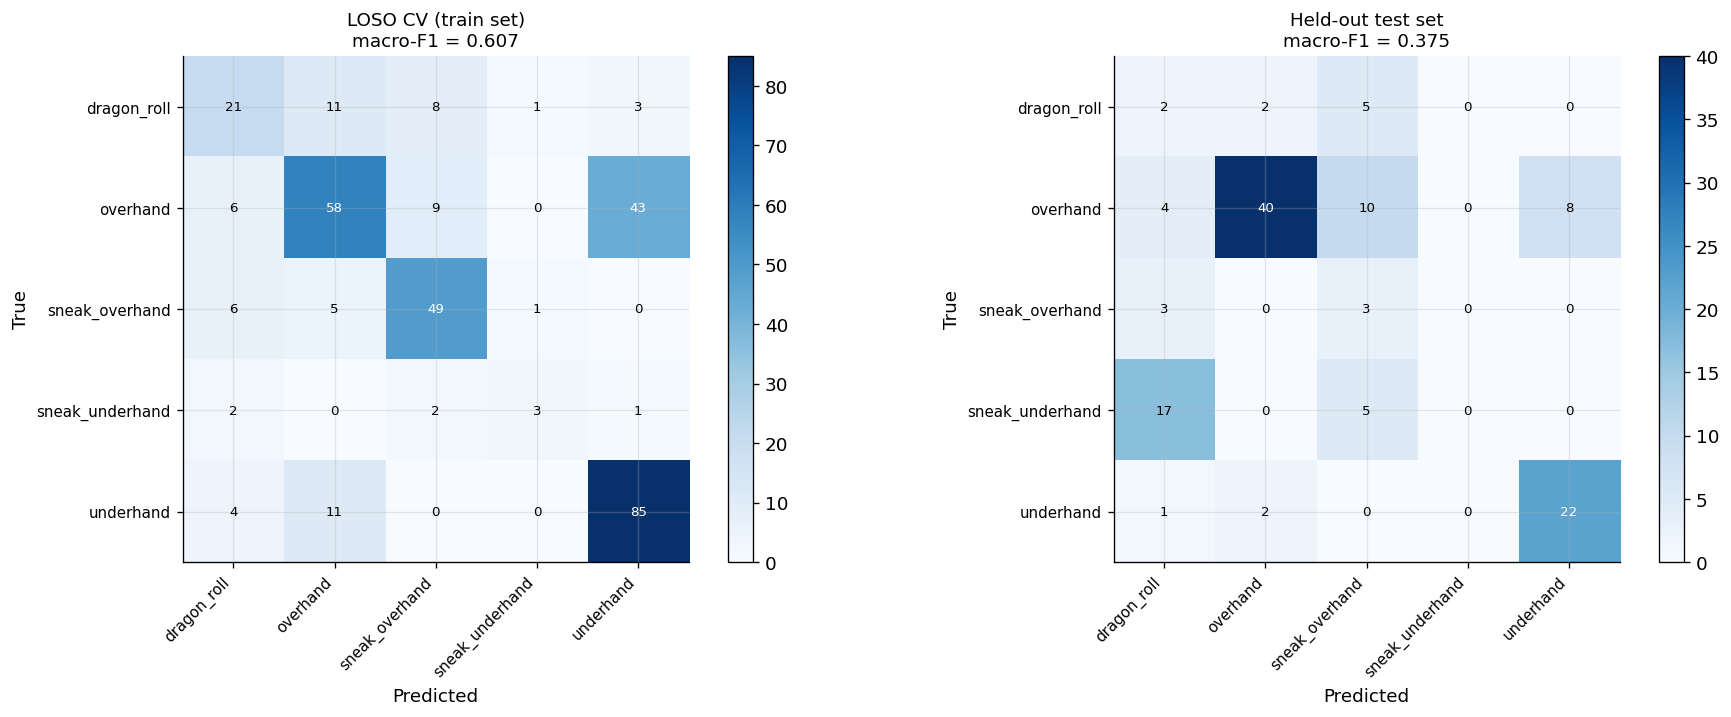

In [24]:
# ── Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, res, title in zip(
    axes,
    [loso_results, test_results],
    ['LOSO CV (train set)', 'Held-out test set']
):
    if 'fine_cm' not in res:
        ax.set_title(f'{title} — no data'); continue
    cm = res['fine_cm']
    classes = res['fine_classes']
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()*0.5 else 'black', fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    f1 = res.get('fine_f1_macro', res.get('test_f1_macro', 0))
    ax.set_title(f'{title}\nmacro-F1 = {f1:.3f}', fontsize=11)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_v05_confusion_matrices.png'), bbox_inches='tight')
plt.show()


### 8.2  LOSO vs test F1 comparison

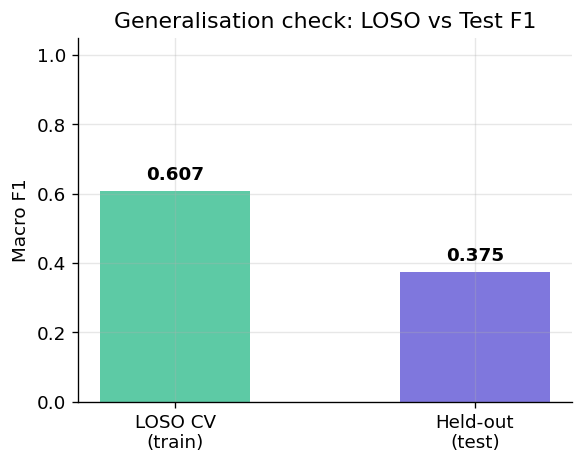

In [25]:
# ── LOSO vs Test F1 comparison bar chart ─────────────────────────────
loso_f1  = loso_results.get('fine_f1_macro', 0)
test_f1  = test_results.get('test_f1_macro', 0)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['LOSO CV\n(train)', 'Held-out\n(test)'], [loso_f1, test_f1],
              color=['#5DCAA5', '#7F77DD'], width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1')
ax.set_title('Generalisation check: LOSO vs Test F1')
for bar, val in zip(bars, [loso_f1, test_f1]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_v05_f1_comparison.png'), bbox_inches='tight')
plt.show()


### 8.3  Feature importance (tier-colored)

mean_omega_d1: 0.077981
phase_xy_d0: 0.066746
mean_omega_d0: 0.055340
winding_rate_d0: 0.050525
phase_yz_d1: 0.050348
phase_yz_d0: 0.043127
omega_ratio_d1d0: 0.035919
plane_ratio_d1: 0.032469
total_energy: 0.030014
phase_xz_d1: 0.026930
phase_xz_d0: 0.026676
acc_rms_d1: 0.024947
plane_ratio_d0: 0.022754
peak_omega_ratio: 0.019563
acc_rms_d0: 0.016863
acc_asymmetry: 0.016290
jerk_rms: 0.014423
ke_ratio: 0.013711
shape_pc_4: 0.013698
acc_mag_spec_centroid: 0.013675


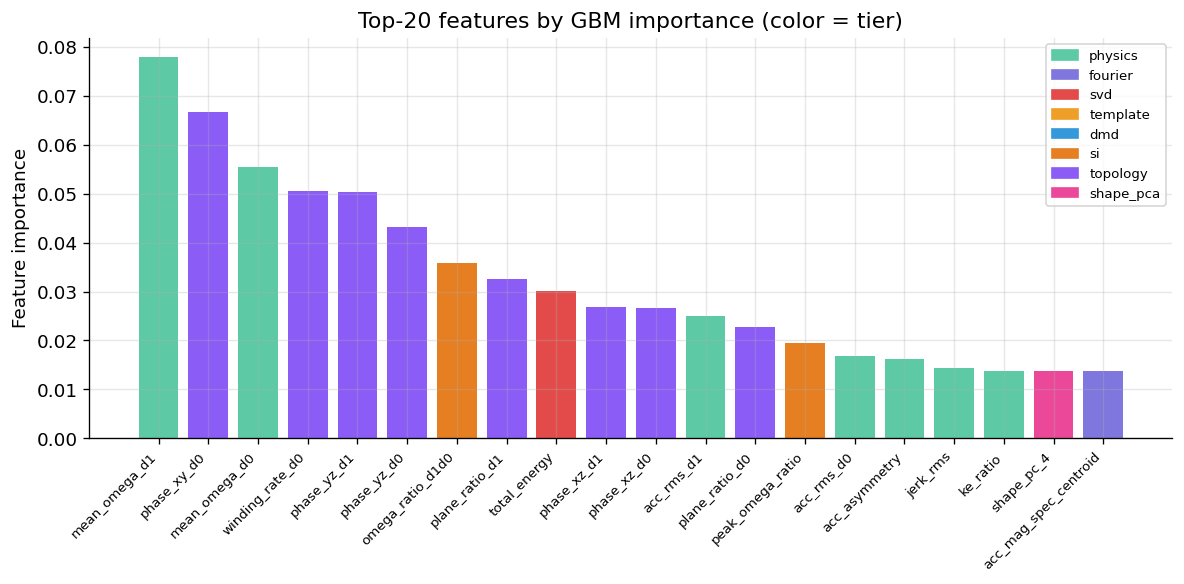

In [28]:
# ── Feature importance (tier-colored) ────────────────────────────────
TIER_COLORS = {
    'physics': '#5DCAA5', 'fourier': '#7F77DD',
    'svd': '#E24B4A', 'template': '#EF9F27',
    'dmd': '#3498db', 'si': '#e67e22',
    'topology': '#8B5CF6', 'shape_pca': '#EC4899',
}
TIER_RANGES = {
    'physics':  (0,  12),
    'fourier':  (12, 28),
    'svd':      (28, 36),
    'template': (36, 38),
    'dmd':      (38, 47),
    'si':       (47, 56),
    'topology': (56, 66),
    'shape_pca':(66, 76),
}
def get_tier(name):
    idx = ALL_FEAT_NAMES.index(name) if name in ALL_FEAT_NAMES else -1
    for tier, (lo, hi) in TIER_RANGES.items():
        if lo <= idx < hi:
            return tier
    return 'other'

imp = MODEL_FINAL['clf'].feature_importances_
feat_names = MODEL_FINAL['feature_names']
order = np.argsort(imp)[::-1][:20]
top20 = [(feat_names[i], imp[i]) for i in order]
for name, val in top20:
    print(f"{name}: {val:.6f}")
colors = [TIER_COLORS.get(get_tier(feat_names[i]), '#aaa') for i in order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(order)), imp[order], color=colors)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([feat_names[i] for i in order], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Feature importance')
ax.set_title('Top-20 features by GBM importance (color = tier)')
from matplotlib.patches import Patch
patches = [Patch(color=c, label=t) for t, c in TIER_COLORS.items()]
ax.legend(handles=patches, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig_v05_feature_importance.png'), bbox_inches='tight')
plt.show()


---
## 9. Summary

In [27]:
# ── Pipeline summary ─────────────────────────────────────────────────
print('='*80)
print('V07 PIPELINE SUMMARY')
print('='*80)
print(f'  Total sessions     : {len(ALL_SESSIONS)} entries '
      f'({sum(1 for e in ALL_SESSIONS if e[4] is None)} homogeneous, '
      f'{sum(1 for e in ALL_SESSIONS if e[4] is not None)} heterogeneous)')
print(f'  Train entries      : {len(TRAIN_SESSIONS)}')
print(f'  Test  entries      : {len(TEST_SESSIONS)}')
print(f'  LOSO  macro-F1     : {loso_results.get("fine_f1_macro",0):.3f}')
print(f'  Test  macro-F1     : {test_results.get("test_f1_macro",0):.3f}')
n_train_cycles = MODEL_FINAL["X_train"].shape[0]
print(f'  Training cycles    : {n_train_cycles}')
print(f'  Feature dim        : {MODEL_FINAL["X_train"].shape[1]}')
print(f'  Classes            : {list(MODEL_FINAL["label_encoder"].classes_)}')


V07 PIPELINE SUMMARY
  Total sessions     : 66 entries (11 homogeneous, 55 heterogeneous)
  Train entries      : 55
  Test  entries      : 11
  LOSO  macro-F1     : 0.607
  Test  macro-F1     : 0.375
  Training cycles    : 1687
  Feature dim        : 76
  Classes            : [np.str_('dragon_roll'), np.str_('overhand'), np.str_('sneak_overhand'), np.str_('sneak_underhand'), np.str_('underhand')]
